# 2.1 探索性数据分析 EDA

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
display.set_matplotlib_formats('svg') # 使用svg分辨率更高

C:\Users\13174\AppData\Local\Temp\ipykernel_27696\181224766.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg') # 使用svg分辨率更高


In [17]:
# data = pd.read_csv('../chap1_data/zillow_data.csv')
data = pd.read_feather('house_sales.ftr')

# # 1. 统一处理缺失值标记
# data = data.replace('No Data', np.nan)

# 强制尝试自动类型转换
data = data.apply(pd.to_numeric, errors='ignore')

In [18]:
data.shape

(164944, 1789)

In [19]:
data.head() # 元数据

,Id,Address,Sold Price,Sold On,Summary,Type,Year built,Heating,Cooling,Parking,...,Well Disclosure,remodeled,DOH2,SerialX,Full Baths,Tax Legal Lot Number,Tax Legal Block Number,Tax Legal Tract Number,Building Name,Zip
0,2080183300,"11205 Monterey,","$2,000,000",01/31/20,"11205 Monterey, San Martin, CA 95046 is a sing...",SingleFamily,No Data,No Data,No Data,0 spaces,...,None,NaN,None,None,None,NaN,NaN,None,None,95046
1,20926300,"5281 Castle Rd,","$2,100,000",02/25/21,Spectacular Mountain and incredible L.A. City ...,SingleFamily,1951,Central,"Central Air, Dual","Driveway, Driveway - Brick",...,None,NaN,None,None,None,NaN,NaN,None,None,91011
2,19595300,"3581 Butcher Dr,","$1,125,000",11/06/19,Eichler Style home! with Santa Clara High! in ...,SingleFamily,1954,Central Forced Air - Gas,Central AC,"Garage, Garage - Attached, Covered",...,None,NaN,None,None,None,NaN,NaN,None,None,95051
3,300472200,"2021 N Milpitas Blvd,","$36,250,000",10/02/20,"2021 N Milpitas Blvd, Milpitas, CA 95035 is a ...",Apartment,1989,Other,No Data,"Mixed, Covered",...,None,NaN,None,None,None,NaN,NaN,None,None,95035
4,2074492000,"LOT 4 Tool Box Spring Rd,","$140,000",10/19/20,Beautiful level lot dotted with pine trees ro...,VacantLand,No Data,No Data,No Data,0 spaces,...,None,NaN,None,None,None,NaN,NaN,None,None,92561


## 数据格式化

丢弃 30%数据为null 的列，简化EDA

In [20]:
null_sum = data.isnull().sum()
data.columns[null_sum < len(data) * 0.3]  # 检查 columns to keep
# 先查看后 drop, 不然会报错

Index(['Id', 'Address', 'Sold Price', 'Sold On', 'Summary', 'Type',
       'Year built', 'Heating', 'Cooling', 'Parking', 'Bedrooms', 'Bathrooms',
       'Total interior livable area', 'Total spaces', 'Garage spaces',
       'Home type', 'Region', 'Elementary School', 'Elementary School Score',
       'Elementary School Distance', 'High School', 'High School Score',
       'High School Distance', 'Heating features', 'Parking features',
       'Lot size', 'Parcel number', 'Tax assessed value', 'Annual tax amount',
       'Listed On', 'Listed Price', 'Zip'],
      dtype='object')

In [21]:
data.drop(columns=data.columns[null_sum > len(data) * 0.3], inplace=True) # 丢弃对应列

In [22]:
data.dtypes

Id                               int64
Address                         object
Sold Price                      object
Sold On                         object
Summary                         object
Type                            object
Year built                      object
Heating                         object
Cooling                         object
Parking                         object
Bedrooms                        object
Bathrooms                      float64
Total interior livable area     object
Total spaces                   float64
Garage spaces                  float64
Home type                       object
Region                          object
Elementary School               object
Elementary School Score        float64
Elementary School Distance     float64
High School                     object
High School Score              float64
High School Distance           float64
Heating features                object
Parking features                object
Lot size                 

将价格字符串转为浮点数

In [23]:
currency = ['Sold Price', 'Listed Price', 'Tax assessed value', 'Annual tax amount']
for c in currency:
    data[c] = data[c].replace(
        r'[$,-]', '', regex=True
    ).replace(
        r'^\s*$', np.nan, regex=True
    ).astype(float)
    

将面积字符串转为浮点数

In [24]:
areas = ['Total interior livable area', 'Lot size']
for c in areas:
    acres = data[c].str.contains('Acres') == True
    col = data[c].replace(
        r'\b sqft\b|\b Acres\b|\b,\b','', regex=True
    ).astype(float)
    col[acres] *= 43560
    data[c] = col

## 数据分析+清洗

In [ ]:
# 检查数据统计信息，分析不合理处
'''
不合理的数据：
# 1. 卫生间最大值不合理：256个
# 2. 可居住面积(feet square)平均值 300 平，最大值 1600 万平

合理的数据：
# 美国小学评分 1-10 正常
'''
data.describe()

'\n不合理的数据：\n# 1. 卫生间最大值不合理：256个\n# 2. 可居住面积(feet square)平均值 300 平，最大值 1600 万平\n\n合理的数据：\n# 美国小学评分 1-10 正常\n'

丢弃面积小于 1 平米，大于 1 万平米的房子

In [26]:
print(len(data))
abnormal = (data[areas[1]] < 10) | (data[areas[1]] > 1e4)
data = data[~abnormal]
sum(abnormal) # 丢弃数量: 1/4

164944


41000

检查房价分布直方图histogram：价格一般使用 log10 分析和预测

'\n前面的小峰值可能是出租价格，属于噪音\n'

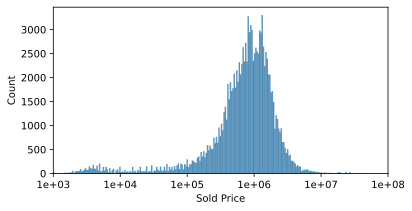

In [ ]:
'''
前面的小峰值可能是出租价格，属于噪音
'''
_, ax = plt.subplots(figsize=(6, 3))
ax = sns.histplot(np.log10(data['Sold Price']), ax = ax)
ax.set_xlim([3, 8]) # 设置 X 轴的显示范围
ax.set_xticks(range(3, 9)) # 手动指定坐标轴上刻度线（Tick Marks）出现的位置：[3, 4, 5, 6, 7, 8]
ax.set_xticklabels(['%.0e'%a for a in 10**ax.get_xticks()]) # 设置刻度标签

统计房型类别

In [32]:
data['Type'].value_counts()[0:20]

Type
SingleFamily            74318
Condo                   18749
MultiFamily              6586
VacantLand               6199
Townhouse                5846
Unknown                  5390
MobileManufactured       2588
Apartment                1416
Cooperative               161
Residential Lot            75
Single Family              69
Single Family Lot          56
Acreage                    48
2 Story                    39
3 Story                    25
Hi-Rise (9+), Luxury       21
RESIDENTIAL                19
Duplex                     19
Condominium                19
Mid-Rise (4-8)             17
Name: count, dtype: int64

统计不同房型的房价分布概率(density)

e:\Anaconda3\envs\d2l\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


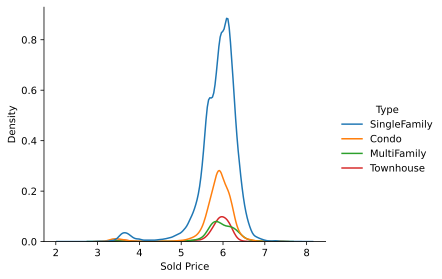

In [45]:
types = data['Type'].isin(['SingleFamily', 'Condo', 'MultiFamily', 'Townhouse'])
sns.displot(
    pd.DataFrame({'Sold Price':np.log10(data[types]['Sold Price']),
                          'Type':data[types]['Type']}),
    x='Sold Price', hue='Type', kind='kde', height=4, aspect=1.2) # 宽高比

统计不同房型的单位feet square的价格，箱线图 box plot

C:\Users\13174\AppData\Local\Temp\ipykernel_27696\534201859.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


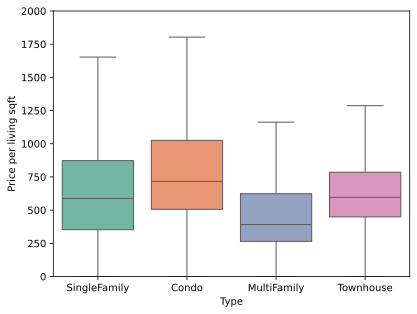

In [49]:
data['Price per living sqft'] = data['Sold Price'] / data['Total interior livable area']
# data[types] 指定types中四类房型数据源
# x,y 指定绘图使用的data中的key
ax = sns.boxplot(
    x='Type', y='Price per living sqft', 
    data=data[types], fliersize=0, palette='Set2'
    )
ax.set_ylim([0, 2000]);

统计位置对房价的影响：房子最多的前 20 个邮政编码(zip codes)

C:\Users\13174\AppData\Local\Temp\ipykernel_27696\2575389544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\13174\AppData\Local\Temp\ipykernel_27696\2575389544.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


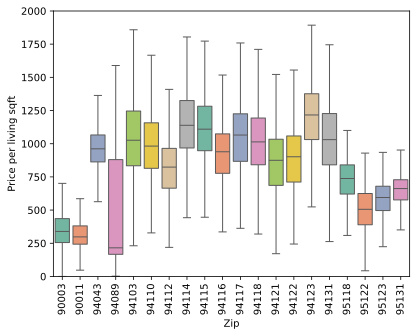

In [53]:
d = data[data['Zip'].isin(data['Zip'].value_counts()[:20].keys())]
ax = sns.boxplot(
    x='Zip', y='Price per living sqft', 
    data=d, fliersize=0, palette='Set2')
ax.set_ylim([0, 2000])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
pass

### 分析不同特征之间的关系

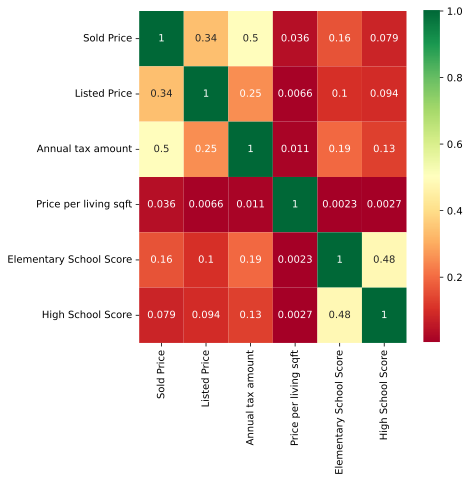

In [ ]:
'''
年税：和房价关联最大
学区：和房价有一定关联
小学和高中评分有很大关联
'''
_, ax = plt.subplots(figsize=(6,6))
columns = ['Sold Price', 'Listed Price', 'Annual tax amount', 'Price per living sqft', 'Elementary School Score', 'High School Score']
sns.heatmap(data[columns].corr(),annot=True,cmap='RdYlGn', ax=ax)